# Taller Practico 3 - Deteccion de Trayectoria de Asteroides
## Procesamiento de Video: CPU Secuencial vs GPU Paralelo (CUDA)

**Universidad Sergio Arboleda - Marzo 2026**

**Autores:**

 - Kevin García
 - Karol Guerrero
 - Juan Márquez
---

### Pipeline de procesamiento
```
Video .mp4  ->  Escala de grises  ->  Diferencia temporal
            ->  Filtro espacial (blur 3x3 sobre diferencia)
            ->  Umbralización (fija o adaptativa: media + k*std)
            ->  Morfologia (erosion + dilatacion)
            ->  Extraccion de centroide  ->  Trayectoria + Veredicto
```

> **Nota:** Activa la GPU en `Entorno de ejecucion -> Cambiar tipo de entorno -> T4 GPU` antes de ejecutar.

---
## Celda 1 - Instalacion de dependencias

Ejecutar **una sola vez** al iniciar el entorno. No es necesario volver a ejecutar al cambiar el video.

In [ ]:
!pip install -q opencv-python-headless numpy matplotlib numba

---
## Celda 2 - Importaciones y verificacion de entorno

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import math
import warnings
warnings.filterwarnings('ignore')

try:
    from numba import cuda
    import numba
    CUDA_AVAILABLE = cuda.is_available()
except ImportError:
    CUDA_AVAILABLE = False

print(f'OpenCV         : {cv2.__version__}')
print(f'NumPy          : {np.__version__}')
try:
    print(f'Numba          : {numba.__version__}')
except:
    pass
print(f'CUDA disponible: {CUDA_AVAILABLE}')
if CUDA_AVAILABLE:
    print(f'GPU            : {cuda.get_current_device().name}')

OpenCV         : 4.13.0
NumPy          : 2.0.2
Numba          : 0.60.0
CUDA disponible: True
GPU            : Tesla T4


---
## Celda 3 - Kernels CUDA

Se definen los kernels que operan enteramente en VRAM. Los buffers intermedios nunca regresan a RAM entre etapas; solo se hace una transferencia de subida y una de bajada por frame.

| Kernel | Etapa |
|---|---|
| `kernel_rgb2gray` | Conversion a escala de grises |
| `kernel_absdiff` | Diferencia absoluta entre frames (sustraccion de fondo) |
| `kernel_blur3x3` | Promedio de vecindad 3x3 aplicado sobre el mapa de diferencias |
| `kernel_threshold` | Binarizacion con umbral calculado en CPU, aplicado en GPU |
| `kernel_erode` | Erosion morfologica 3x3 |
| `kernel_dilate` | Dilatacion morfologica 3x3 |

In [ ]:
if CUDA_AVAILABLE:
    from numba import cuda

    @cuda.jit
    def kernel_rgb2gray(src, dst):
        """Cada hilo convierte un pixel (R,G,B) a luminancia Y."""
        x, y = cuda.grid(2)
        H, W, _ = src.shape
        if x < H and y < W:
            r = src[x, y, 2] * 0.299
            g = src[x, y, 1] * 0.587
            b = src[x, y, 0] * 0.114
            dst[x, y] = r + g + b

    @cuda.jit
    def kernel_absdiff(frame_t, frame_prev, dst):
        """D(x,y) = |I_t(x,y) - I_{t-1}(x,y)|  (seccion 3.2)."""
        x, y = cuda.grid(2)
        H, W = frame_t.shape
        if x < H and y < W:
            diff = frame_t[x, y] - frame_prev[x, y]
            dst[x, y] = diff if diff >= 0 else -diff

    @cuda.jit
    def kernel_blur3x3(src, dst):
        """Promedio 3x3 aplicado sobre el mapa de diferencias."""
        x, y = cuda.grid(2)
        H, W = src.shape
        if 1 <= x < H - 1 and 1 <= y < W - 1:
            total = 0.0
            for dx in range(-1, 2):
                for dy in range(-1, 2):
                    total += src[x + dx, y + dy]
            dst[x, y] = total / 9.0
        else:
            if x < H and y < W:
                dst[x, y] = src[x, y]

    @cuda.jit
    def kernel_threshold(src, dst, thresh):
        """Binariza: pixel >= thresh -> 255, si no -> 0."""
        x, y = cuda.grid(2)
        H, W = src.shape
        if x < H and y < W:
            dst[x, y] = 255 if src[x, y] >= thresh else 0

    @cuda.jit
    def kernel_erode(src, dst):
        """Erosion 3x3: el pixel central es 255 solo si todos en 3x3 son 255."""
        x, y = cuda.grid(2)
        H, W = src.shape
        if 1 <= x < H - 1 and 1 <= y < W - 1:
            min_val = 255
            for dx in range(-1, 2):
                for dy in range(-1, 2):
                    if src[x + dx, y + dy] < min_val:
                        min_val = src[x + dx, y + dy]
            dst[x, y] = min_val
        else:
            if x < H and y < W:
                dst[x, y] = 0

    @cuda.jit
    def kernel_dilate(src, dst):
        """Dilatacion 3x3: si al menos un vecino es 255, el central -> 255."""
        x, y = cuda.grid(2)
        H, W = src.shape
        if 1 <= x < H - 1 and 1 <= y < W - 1:
            max_val = 0
            for dx in range(-1, 2):
                for dy in range(-1, 2):
                    if src[x + dx, y + dy] > max_val:
                        max_val = src[x + dx, y + dy]
            dst[x, y] = max_val
        else:
            if x < H and y < W:
                dst[x, y] = 0

    print('Kernels CUDA compilados correctamente.')
else:
    print('CUDA no disponible. Solo se ejecutara la version CPU.')

Kernels CUDA compilados correctamente.


---
## Celda 4 - Clase AsteroidDetector

El objeto encapsula todo el pipeline. Se configura al instanciar:

```python
# Umbral adaptativo (recomendado), usando GPU
detector = AsteroidDetector(video_path, use_gpu=True)

# Umbral fijo manual, en CPU
detector = AsteroidDetector(video_path, use_gpu=False, adaptive_threshold=False, threshold=30)

# Umbral adaptativo con k personalizado
detector = AsteroidDetector(video_path, use_gpu=True, adaptive_k=3.0)
```

**Parametros de umbral:**
- `adaptive_threshold=True` (default): `umbral = media + adaptive_k * desviacion_estandar` del mapa de diferencias de cada frame
- `adaptive_threshold=False`: usa el valor fijo de `threshold`
- `adaptive_k`: controla la sensibilidad. Bajar = mas detecciones. Subir = menos falsos positivos. Rango sugerido: 1.5 a 3.0

**Nota sobre el orden del pipeline (corregido respecto a version anterior):**
El blur ahora se aplica **despues** de la diferencia temporal, no antes. Aplicarlo antes reducia la intensidad del asteroide antes de restar, haciendo que quedara por debajo del umbral incluso siendo visible al ojo humano.

In [ ]:
class AsteroidDetector:
    """
    Pipeline de deteccion de asteroides: CPU secuencial o GPU paralelo (CUDA).

    Parametros
    ----------
    video_path          : str   -- ruta al archivo .mp4
    use_gpu             : bool  -- True -> CUDA, False -> CPU
    adaptive_threshold  : bool  -- True -> umbral = media + k*std  (default)
                                   False -> umbral fijo (valor de 'threshold')
    threshold           : int   -- umbral fijo, usado solo si adaptive_threshold=False
    adaptive_k          : float -- multiplicador de std para umbral adaptativo
                                   (recomendado 3.0-3.5 para videos con ruido)
    min_area            : int   -- area minima de contorno para considerar deteccion
    smooth_window       : int   -- ventana de media movil para suavizar trayectoria
                                   (0 = sin suavizado)
    """

    def __init__(self,
                 video_path         : str,
                 use_gpu            : bool  = False,
                 adaptive_threshold : bool  = True,
                 threshold          : int   = 30,
                 adaptive_k         : float = 3.0,
                 min_area           : int   = 20,
                 smooth_window      : int   = 5):

        self.video_path          = video_path
        self.use_gpu             = use_gpu and CUDA_AVAILABLE
        self.adaptive_threshold  = adaptive_threshold
        self.threshold           = threshold
        self.adaptive_k          = adaptive_k
        self.min_area            = min_area
        self.smooth_window       = smooth_window
        self.mode                = 'GPU (CUDA)' if self.use_gpu else 'CPU (Secuencial)'
        self.thresh_mode         = (f'Adaptativo (k={adaptive_k})'
                                    if adaptive_threshold else f'Fijo ({threshold})')

        # Resultados
        self.trajectory  = []
        self.elapsed     = 0.0
        self.verdict     = None
        self.frame_count = 0
        self.first_frame = None

    # -----------------------------------------------------------------
    # Calculo del umbral
    # -----------------------------------------------------------------
    def _compute_threshold(self, diff_array: np.ndarray) -> float:
        if self.adaptive_threshold:
            return float(diff_array.mean() + self.adaptive_k * diff_array.std())
        return float(self.threshold)

    # -----------------------------------------------------------------
    # FIX 3: Calculo del umbral en GPU con CuPy para evitar bajada a RAM
    # -----------------------------------------------------------------
    def _compute_threshold_gpu(self, d_blurred) -> float:
        """
        Calcula mean y std directamente en VRAM usando CuPy.
        Evita la transferencia d_blurred.copy_to_host() frame a frame.
        Solo baja dos escalares (mean, std) en lugar de toda la imagen.
        """
        try:
            import cupy as cp
            # Envuelve el buffer Numba como array CuPy sin copiar datos
            arr = cp.asarray(d_blurred)
            mean = float(cp.mean(arr))
            std  = float(cp.std(arr))
        except ImportError:
            # Fallback si CuPy no esta disponible: bajada minima
            arr  = d_blurred.copy_to_host()
            mean = float(arr.mean())
            std  = float(arr.std())

        if self.adaptive_threshold:
            return mean + self.adaptive_k * std
        return float(self.threshold)

    # -----------------------------------------------------------------
    # Pipeline CPU
    # -----------------------------------------------------------------
    def _process_frame_cpu(self, frame_bgr: np.ndarray,
                            prev_gray: np.ndarray) -> tuple:
        kernel = np.ones((3, 3), np.float32) / 9.0

        gray         = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)
        diff         = cv2.absdiff(gray, prev_gray)
        diff_blurred = cv2.filter2D(diff, -1, kernel)

        thresh_val = self._compute_threshold(diff_blurred)
        _, binary  = cv2.threshold(
            diff_blurred.astype(np.uint8), int(thresh_val), 255, cv2.THRESH_BINARY)

        k_morph = np.ones((3, 3), np.uint8)
        mask    = cv2.dilate(cv2.erode(binary, k_morph), k_morph)

        return mask, gray

    # -----------------------------------------------------------------
    # Pipeline GPU — buffers permanecen en VRAM entre kernels
    # -----------------------------------------------------------------
    def _process_frame_gpu(self, frame_bgr: np.ndarray,
                            d_prev_gray) -> tuple:
        H, W, _ = frame_bgr.shape
        tpb = (16, 16)
        bpg = (math.ceil(H / tpb[0]), math.ceil(W / tpb[1]))

        d_frame   = cuda.to_device(frame_bgr.astype(np.float32))
        d_gray    = cuda.device_array((H, W), dtype=np.float32)
        d_diff    = cuda.device_array((H, W), dtype=np.float32)
        d_blurred = cuda.device_array((H, W), dtype=np.float32)
        d_binary  = cuda.device_array((H, W), dtype=np.uint8)
        d_eroded  = cuda.device_array((H, W), dtype=np.uint8)
        d_mask    = cuda.device_array((H, W), dtype=np.uint8)

        kernel_rgb2gray[bpg, tpb](d_frame, d_gray)
        kernel_absdiff[bpg, tpb](d_gray, d_prev_gray, d_diff)
        kernel_blur3x3[bpg, tpb](d_diff, d_blurred)

        # FIX 3: umbral calculado en VRAM, solo bajan dos escalares
        thresh_val = self._compute_threshold_gpu(d_blurred)

        kernel_threshold[bpg, tpb](d_blurred, d_binary, np.float32(thresh_val))
        kernel_erode[bpg, tpb](d_binary, d_eroded)
        kernel_dilate[bpg, tpb](d_eroded, d_mask)

        mask = d_mask.copy_to_host()
        return mask, d_gray

    # -----------------------------------------------------------------
    # FIX 1: Centroide del contorno mas grande (no promedio global)
    # -----------------------------------------------------------------
    def _find_centroid(self, mask: np.ndarray):
        """
        Encuentra contornos individuales y selecciona el de mayor area.
        Descarta contornos menores a min_area para ignorar ruido residual.
        Retorna el centroide del contorno mas grande, o None si no hay
        ninguno que supere min_area.
        """
        contours, _ = cv2.findContours(
            mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if not contours:
            return None

        # Seleccionar el contorno de mayor area
        largest = max(contours, key=cv2.contourArea)
        area    = cv2.contourArea(largest)

        if area < self.min_area:
            return None

        # Centroide via momentos del contorno
        M = cv2.moments(largest)
        if M['m00'] == 0:
            return None

        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
        return cx, cy

    # -----------------------------------------------------------------
    # FIX 4: Suavizado de trayectoria por media movil
    # -----------------------------------------------------------------
    def _smooth_trajectory(self, trajectory: list) -> list:
        """
        Aplica media movil de ventana smooth_window sobre las coordenadas
        x e y de la trayectoria para eliminar saltos por ruido puntual.
        Si smooth_window <= 1 devuelve la trayectoria sin cambios.
        """
        if self.smooth_window <= 1 or len(trajectory) < self.smooth_window:
            return trajectory

        frames = [t[0] for t in trajectory]
        xs     = np.array([t[1] for t in trajectory], dtype=float)
        ys     = np.array([t[2] for t in trajectory], dtype=float)

        w       = self.smooth_window
        kernel  = np.ones(w) / w
        xs_smooth = np.convolve(xs, kernel, mode='same')
        ys_smooth = np.convolve(ys, kernel, mode='same')

        # Los extremos del convolve 'same' tienen menos muestras reales;
        # se reemplazan con los valores originales para no distorsionar
        # el inicio y fin de la trayectoria.
        half = w // 2
        xs_smooth[:half]  = xs[:half]
        xs_smooth[-half:] = xs[-half:]
        ys_smooth[:half]  = ys[:half]
        ys_smooth[-half:] = ys[-half:]

        return [(f, int(x), int(y))
                for f, x, y in zip(frames, xs_smooth, ys_smooth)]

    # -----------------------------------------------------------------
    # Metodo principal
    # -----------------------------------------------------------------
    def run(self) -> dict:
        print(f'Pipeline [{self.mode}] | Umbral: {self.thresh_mode}')
        print(f'Video: {self.video_path}')

        cap = cv2.VideoCapture(self.video_path)
        if not cap.isOpened():
            raise FileNotFoundError(f'No se pudo abrir: {self.video_path}')

        self.frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        self.trajectory  = []

        ret, frame = cap.read()
        if not ret:
            raise RuntimeError('El video esta vacio.')

        self.first_frame = frame.copy()

        if self.use_gpu:
            first_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)
            prev_gray  = cuda.to_device(first_gray)
        else:
            prev_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)

        idx   = 1
        start = time.perf_counter()

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if self.use_gpu:
                mask, prev_gray = self._process_frame_gpu(frame, prev_gray)
            else:
                mask, prev_gray = self._process_frame_cpu(frame, prev_gray)

            centroid = self._find_centroid(mask)
            if centroid is not None:
                self.trajectory.append((idx, centroid[0], centroid[1]))

            idx += 1

        cap.release()
        self.elapsed = time.perf_counter() - start

        # FIX 4: suavizar trayectoria antes del veredicto final
        self.trajectory = self._smooth_trajectory(self.trajectory)
        self.verdict    = 'Existe Asteroide' if self.trajectory else 'No Existe Asteroide'

        print(f'  Frames procesados : {idx - 1}')
        print(f'  Detecciones       : {len(self.trajectory)}')
        print(f'  Tiempo total      : {self.elapsed:.3f} s')
        print(f'  Veredicto         : {self.verdict}\n')

        return {
            'mode'        : self.mode,
            'thresh_mode' : self.thresh_mode,
            'verdict'     : self.verdict,
            'trajectory'  : self.trajectory,
            'elapsed'     : self.elapsed,
            'frames'      : idx - 1,
            'fps_proc'    : (idx - 1) / self.elapsed,
            'first_frame' : self.first_frame,
        }

---
## Celda 5 - Subida del video

Ejecuta esta celda cada vez que quieras cambiar el video de prueba. Las celdas 1 a 4 no necesitan volver a ejecutarse.

In [ ]:
from google.colab import files
import os

print('Selecciona el archivo de video (.mp4):')
uploaded   = files.upload()
VIDEO_PATH = list(uploaded.keys())[0]
print(f'Video cargado: {VIDEO_PATH}  ({os.path.getsize(VIDEO_PATH)/1e6:.2f} MB)')

Selecciona el archivo de video (.mp4):


Saving v1.mp4 to v1.mp4
Video cargado: v1.mp4  (7.22 MB)


---
## Celda 6 - Configuracion y ejecucion de los pipelines

Modifica los parametros aqui antes de ejecutar.

| Parametro | Descripcion |
|---|---|
| `ADAPTIVE_THRESHOLD` | `True` = umbral automatico por frame, `False` = valor fijo |
| `THRESHOLD_FIXED` | Valor fijo, solo activo si `ADAPTIVE_THRESHOLD = False` |
| `ADAPTIVE_K` | Sensibilidad del umbral adaptativo. Bajar = mas detecciones, subir = menos falsos positivos |
| `MIN_AREA` | Cuantos pixeles blancos minimos para declarar deteccion |

`use_gpu` se asigna automaticamente segun disponibilidad de CUDA en el entorno.

In [ ]:
# ── Parametros configurables ───────────────────────────────────────────────
ADAPTIVE_THRESHOLD = True   # True = media + k*std | False = valor fijo
THRESHOLD_FIXED    = 30     # Usado solo si ADAPTIVE_THRESHOLD = False
ADAPTIVE_K         = 2.0    # Multiplicador de std (rango sugerido: 1.5 - 3.0)
MIN_AREA           = 5      # Minimo de pixeles blancos para considerar deteccion
# ──────────────────────────────────────────────────────────────────────────

detector_cpu = AsteroidDetector(
    VIDEO_PATH,
    use_gpu            = False,
    adaptive_threshold = ADAPTIVE_THRESHOLD,
    threshold          = THRESHOLD_FIXED,
    adaptive_k         = ADAPTIVE_K,
    min_area           = MIN_AREA,
)
result_cpu = detector_cpu.run()

detector_gpu = AsteroidDetector(
    VIDEO_PATH,
    use_gpu            = True,
    adaptive_threshold = ADAPTIVE_THRESHOLD,
    threshold          = THRESHOLD_FIXED,
    adaptive_k         = ADAPTIVE_K,
    min_area           = MIN_AREA,
)
result_gpu = detector_gpu.run()

Pipeline [CPU (Secuencial)] | Umbral: Adaptativo (k=2.0)
Video: v1.mp4
  Frames procesados : 119
  Detecciones       : 119
  Tiempo total      : 2.248 s
  Veredicto         : Existe Asteroide

Pipeline [GPU (CUDA)] | Umbral: Adaptativo (k=2.0)
Video: v1.mp4
  Frames procesados : 119
  Detecciones       : 119
  Tiempo total      : 6.419 s
  Veredicto         : Existe Asteroide



---
## Celda 7 - Resultados finales

Tabla resumen + figura con trayectoria CPU, trayectoria GPU y comparativa de rendimiento.

  Modo umbral   : Adaptativo (k=2.0)
  Veredicto CPU : Existe Asteroide
  Veredicto GPU : Existe Asteroide
  Tiempo CPU    : 2.248 s  (52.9 fps)
  Tiempo GPU    : 6.419 s  (18.5 fps)
  Speedup       : 0.35x


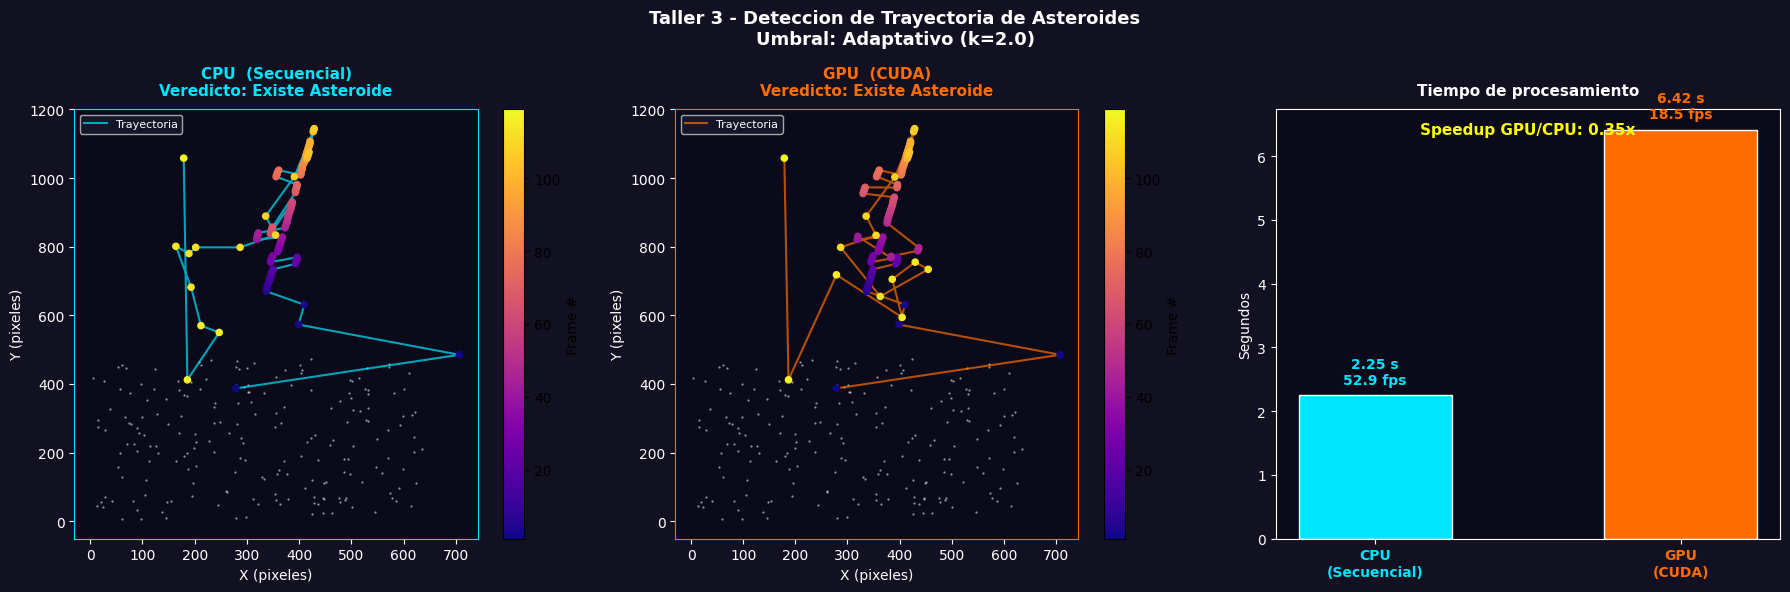

Figura guardada como resultados_asteroides.png


In [ ]:
def plot_results(result_cpu: dict, result_gpu: dict):

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        'Taller 3 - Deteccion de Trayectoria de Asteroides\n'
        f'Umbral: {result_cpu["thresh_mode"]}',
        fontsize=13, fontweight='bold', color='white'
    )
    fig.patch.set_facecolor('#111122')

    def _draw_trajectory(ax, result, color, label):
        traj = result['trajectory']
        ax.set_facecolor('#0a0a1a')
        rng = np.random.default_rng(42)
        ax.scatter(rng.uniform(0, 640, 200), rng.uniform(0, 480, 200),
                   s=0.4, c='white', alpha=0.5, zorder=1)

        if traj:
            frames, xs, ys = zip(*traj)
            sc = ax.scatter(xs, ys, c=frames, cmap='plasma', s=20, zorder=3)
            ax.plot(xs, ys, color=color, linewidth=1.5, alpha=0.7, zorder=2,
                    label='Trayectoria')
            plt.colorbar(sc, ax=ax, label='Frame #')
            ax.legend(fontsize=8, loc='upper left',
                      facecolor='#1a1a2e', labelcolor='white')
        else:
            ax.text(0.5, 0.5, 'Sin detecciones', ha='center', va='center',
                    color='white', transform=ax.transAxes, fontsize=12)

        # Titulo con modo, veredicto y color del modo bien visible
        ax.set_title(
            f'{label}\nVeredicto: {result["verdict"]}',
            color=color, fontsize=11, fontweight='bold', pad=10
        )
        ax.set_xlabel('X (pixeles)', color='white')
        ax.set_ylabel('Y (pixeles)', color='white')
        ax.tick_params(colors='white')
        for spine in ax.spines.values():
            spine.set_edgecolor(color)

    _draw_trajectory(axes[0], result_cpu, '#00e5ff', 'CPU  (Secuencial)')
    _draw_trajectory(axes[1], result_gpu, '#ff6d00', 'GPU  (CUDA)')

    # Comparativa de rendimiento
    ax3     = axes[2]
    modes   = ['CPU\n(Secuencial)', 'GPU\n(CUDA)']
    tiempos = [result_cpu['elapsed'], result_gpu['elapsed']]
    fps_v   = [result_cpu['fps_proc'], result_gpu['fps_proc']]
    bar_colors = ['#00e5ff', '#ff6d00']

    bars = ax3.bar(modes, tiempos, color=bar_colors, width=0.5, edgecolor='white')
    ax3.set_facecolor('#0a0a1a')
    ax3.set_title('Tiempo de procesamiento', color='white', fontsize=11,
                  fontweight='bold', pad=10)
    ax3.set_ylabel('Segundos', color='white')
    ax3.tick_params(colors='white')
    # Etiquetas del eje X con el color de cada modo
    for tick, c in zip(ax3.get_xticklabels(), bar_colors):
        tick.set_color(c)
        tick.set_fontweight('bold')
    for spine in ax3.spines.values():
        spine.set_edgecolor('white')

    for bar, t, fp, c in zip(bars, tiempos, fps_v, bar_colors):
        ax3.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(tiempos) * 0.02,
                 f'{t:.2f} s\n{fp:.1f} fps',
                 ha='center', va='bottom', color=c,
                 fontsize=10, fontweight='bold')

    if result_gpu['elapsed'] > 0:
        speedup = result_cpu['elapsed'] / result_gpu['elapsed']
        ax3.text(0.5, 0.97, f'Speedup GPU/CPU: {speedup:.2f}x',
                 ha='center', va='top', transform=ax3.transAxes,
                 color='yellow', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.savefig('resultados_asteroides.png', dpi=150,
                bbox_inches='tight', facecolor='#111122')
    plt.show()
    print('Figura guardada como resultados_asteroides.png')


# Tabla resumen en consola
sep = '=' * 52
print(sep)
print(f'  Modo umbral   : {result_cpu["thresh_mode"]}')
print(sep)
print(f'  Veredicto CPU : {result_cpu["verdict"]}')
print(f'  Veredicto GPU : {result_gpu["verdict"]}')
print(f'  Tiempo CPU    : {result_cpu["elapsed"]:.3f} s  ({result_cpu["fps_proc"]:.1f} fps)')
print(f'  Tiempo GPU    : {result_gpu["elapsed"]:.3f} s  ({result_gpu["fps_proc"]:.1f} fps)')
if result_gpu['elapsed'] > 0:
    print(f'  Speedup       : {result_cpu["elapsed"]/result_gpu["elapsed"]:.2f}x')
print(sep)

plot_results(result_cpu, result_gpu)

---
## Celda 8 (Opcional) - Calibracion del parametro k

Ejecuta el pipeline con distintos valores de `ADAPTIVE_K` para encontrar el punto optimo entre falsos positivos y detecciones perdidas. No requiere volver a subir el video.

In [ ]:
print(f'Calibracion de adaptive_k sobre: {VIDEO_PATH}\n')
print(f'{"k":>6}  {"Detecciones":>12}  {"Tiempo (s)":>10}  Veredicto')
print('-' * 55)

for k in [1.0, 1.5, 2.0, 2.5, 3.0, 4.0]:
    det = AsteroidDetector(
        VIDEO_PATH,
        use_gpu            = CUDA_AVAILABLE,
        adaptive_threshold = True,
        adaptive_k         = k,
        min_area           = MIN_AREA,
    )
    r = det.run()
    print(f'{k:>6.1f}  {len(r["trajectory"]):>12}  {r["elapsed"]:>10.3f}  {r["verdict"]}')

Calibracion de adaptive_k sobre: v1.mp4

     k   Detecciones  Tiempo (s)  Veredicto
-------------------------------------------------------
Pipeline [GPU (CUDA)] | Umbral: Adaptativo (k=1.0)
Video: v1.mp4
  Frames procesados : 119
  Detecciones       : 119
  Tiempo total      : 3.536 s
  Veredicto         : Existe Asteroide

   1.0           119       3.536  Existe Asteroide
Pipeline [GPU (CUDA)] | Umbral: Adaptativo (k=1.5)
Video: v1.mp4
  Frames procesados : 119
  Detecciones       : 119
  Tiempo total      : 2.683 s
  Veredicto         : Existe Asteroide

   1.5           119       2.683  Existe Asteroide
Pipeline [GPU (CUDA)] | Umbral: Adaptativo (k=2.0)
Video: v1.mp4
  Frames procesados : 119
  Detecciones       : 119
  Tiempo total      : 1.809 s
  Veredicto         : Existe Asteroide

   2.0           119       1.809  Existe Asteroide
Pipeline [GPU (CUDA)] | Umbral: Adaptativo (k=2.5)
Video: v1.mp4
  Frames procesados : 119
  Detecciones       : 119
  Tiempo total      : 1.665 